In [102]:
import os
from pprint import pprint

import pandas as pd
from tqdm import tqdm

In [125]:
OPENDS_NAME         = "USA"
TASK                = "union"
LAKEBENCH_GT_PATH   = f'../data/lakebench/ground truth/opendata_{TASK}_ground_truth.csv' 
OUTPUT_CLEANED_GT   = f'../data/{TASK}/{OPENDS_NAME}_ground_truth.csv'
DATASET_PATH        = f'../data/datasets/datasets_{OPENDS_NAME}.zip'

CLUSTERS_PATH       = f'../data/{TASK}/clusters/clusters_{OPENDS_NAME}.json'

## Create Clusters of Tables with Similar Schema for a given Task

### Load Data and All Tables Schema

In [126]:
clean_task_gt = pd.read_csv(OUTPUT_CLEANED_GT)
clean_task_gt.head()

,query_table,candidate_table
0,USA_CSV0000000000005489.csv,USA_CSV0000000000021514.csv
1,USA_CSV0000000000005707.csv,USA_CSV0000000000031647.csv
2,USA_CSV0000000000005707.csv,USA_CSV0000000000027843.csv
3,USA_CSV0000000000005707.csv,USA_CSV0000000000011253.csv
4,USA_CSV0000000000005707.csv,USA_CSV0000000000014813.csv


In [127]:
from itertools import chain

cat_gt_ids = set(chain(*clean_task_gt.values.tolist()))
print(f'Total tables in {OPENDS_NAME} Ground Truth: {len(cat_gt_ids)}')

Total tables in USA Ground Truth: 537


In [128]:
import unicodedata

def sanitize_column_names(columns):
    """
    Replaces problematic characters in column names with underscores,
    normalizes accents, and strips spaces.
    """
    sanitized_columns = []
    for col in columns:
        # Normalize accents (e.g., é -> e)
        normalized_col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
        # Replace problematic characters with underscores
        sanitized_col = normalized_col.replace('\n', '_').replace(' ', '_').replace('.', '_').strip()
        sanitized_columns.append(sanitized_col)
    return sanitized_columns

In [129]:
import zipfile

errors = []
schema = {}

with zipfile.ZipFile(DATASET_PATH, 'r') as zip_tables:
    table_names = [f.removeprefix(f'datasets_{OPENDS_NAME}/') for f in zip_tables.namelist() if not f.startswith('__MACOSX') and not f.endswith('/') and not f.split('/')[-1].startswith('._')]

    for table_id in tqdm(cat_gt_ids.intersection(table_names)):
        with zip_tables.open(f'datasets_{OPENDS_NAME}/{table_id}', 'r') as table_file:
            try:
                schema[table_id] = sanitize_column_names(pd.read_csv(table_file, nrows=0, low_memory=False).columns)
            except:
                errors.append(table_id)

  0%|          | 0/537 [00:00<?, ?it/s]

100%|██████████| 537/537 [00:01<00:00, 281.48it/s]


In [130]:
errors

[]

In [131]:
len(cat_gt_ids), len(cat_gt_ids.intersection(table_names))

(537, 537)

In [132]:
pprint(schema)

{'USA_CSV0000000000000463.csv': ['datetime_UTC',
                                 'yyyy',
                                 'mm',
                                 'dd',
                                 'HH',
                                 'first_valid_minute',
                                 'last_valid_minute',
                                 'average_measurement_time',
                                 'latitude',
                                 'longitude',
                                 'elevation_m',
                                 'intake_height_m',
                                 'ch4_ppb',
                                 'ch4_uncertainty',
                                 'ch4_SD_raw',
                                 'ch4_n_raw',
                                 'ch4_SD_minutes',
                                 'ch4_n_minutes',
                                 'ch4_min',
                                 'ch4_max',
                                 'ch4_flags'],
 'USA_C

In [133]:
all_attributes = set(chain(*schema.values()))
print(f'Total number of distinct attributes: {len(all_attributes)}')

Total number of distinct attributes: 2922


### LSH Forest

To create the clusters, we can use LSH Forest. For each table, we query the index with its values, and then save the other IDs we have found. 

We can use a table ID only in one cluster, or let it appear into two or more (in this case, we will have more clusters, but maybe more representative because they should have more values)

In [134]:
from datasketch import MinHashLSHForest, MinHash

num_perm = 16
l = 4
lsh_forest = MinHashLSHForest(num_perm=num_perm, l=l)

In [135]:
minhashes = []

for table_id, attributes in tqdm(schema.items(), leave=False):
    m = MinHash(num_perm=num_perm)
    m.update_batch(list(map(str.encode, attributes)))
    minhashes.append((table_id, m))


for table_id, m in tqdm(minhashes, leave=False):
    lsh_forest.add(table_id, m)

lsh_forest.index()

In [136]:
from collections import defaultdict


all_table_ids = set(schema.keys())
clusters = defaultdict(set)

max_num_of_cooccurrences = 1
k = 400

while all_table_ids:
    table_id = all_table_ids.pop()

    # check if the current table is already in any cluster
    if sum(table_id in cluster for cluster in clusters.values()) >= max_num_of_cooccurrences:
        continue
    
    # init the new cluster
    cluster_id = len(clusters)
    clusters[cluster_id].add(table_id)

    # query the index for a large number of results
    mtab = MinHash(num_perm=num_perm)
    mtab.update_batch(list(map(str.encode, schema[table_id])))
    neighbors = lsh_forest.query(mtab, k=k)

    # add each item to the cluster (if it is not in another cluster yet)
    for n in neighbors:
        if sum(n in cluster for cluster in clusters.values()) >= max_num_of_cooccurrences:
            continue
        clusters[cluster_id].add(n)

Number of clusters: 82
Mean size of clusters: 6.548780487804878
min=1, max=36, stdev=8.174263192566224, median=2.0


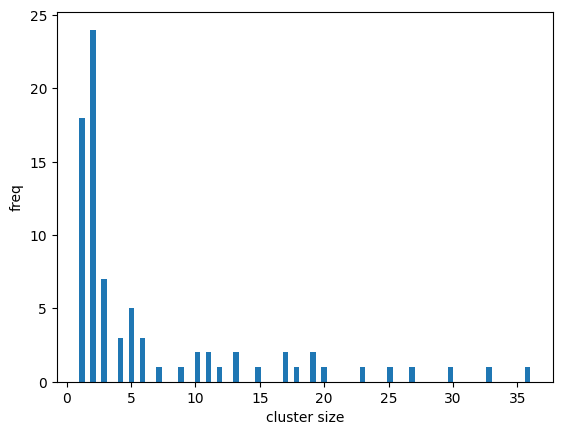

In [137]:
from statistics import *
import matplotlib.pyplot as plt

sizes = [len(cluster) for cluster in clusters.values()]

plt.hist(sizes, bins=len(sizes))
plt.xlabel('cluster size')
plt.ylabel('freq')
print(f'Number of clusters: {len(clusters)}')
print(f'Mean size of clusters: {mean(sizes)}')
print(f'min={min(sizes)}, max={max(sizes)}, stdev={stdev(sizes)}, median={median(sizes)}')

In [138]:
# For each cluster, take all the attributes in its tables' schemas
cluster_attributes = [
    [cluster_key, {attribute for table_id in cluster for attribute in schema[table_id]}]
    for cluster_key, cluster in clusters.items()
]

In [139]:
# Use Jaccard Similarity to compare the clusters
duplicates = {
    ckey_i: {
        ckey_j: len(attributes_i & attributes_j) / len(attributes_i | attributes_j)
        for ckey_j, attributes_j in cluster_attributes
    }
    for ckey_i, attributes_i in cluster_attributes
}

The clusters seems to be enough uncorrelated (?) according to Jaccard Similarity

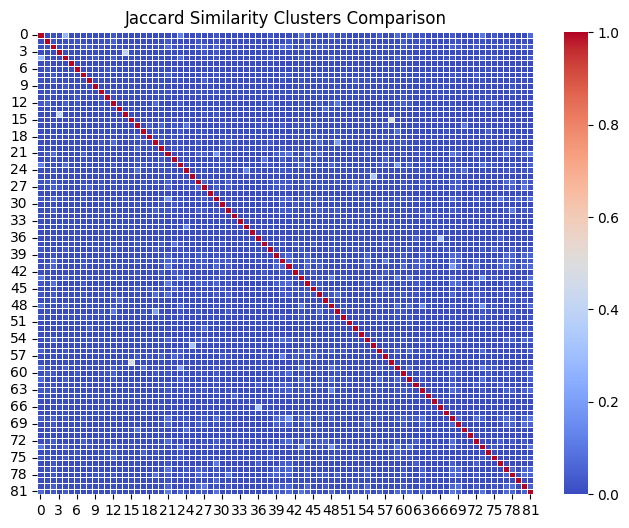

In [140]:
import seaborn as sns

df = pd.DataFrame(duplicates)

plt.figure(figsize=(8, 6))
plt.title('Jaccard Similarity Clusters Comparison')
sns.heatmap(df, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.show()

In [141]:
cluster_attributes_dict = {ckey: list(cschema) for ckey, cschema in cluster_attributes}

In [142]:
import json

if not os.path.exists(os.path.dirname(CLUSTERS_PATH)):
    os.mkdir(os.path.dirname(CLUSTERS_PATH))
    
with open(CLUSTERS_PATH, 'w') as fw:
    json.dump({
        'max_num_of_cooccurrences': max_num_of_cooccurrences,
        'num_perm': num_perm,
        'l': l,
        'k': k,
        'clusters': [
            {
                'key': ckey, 
                'schema': cluster_attributes_dict[ckey],
                'cluster': list(cluster)

            } for ckey, cluster in clusters.items()
        ]
        
    }, fw, indent=4)

### Every table pair in the Ground Truth is present in any cluster?

In [ ]:
gt_pairs = set(map(tuple, clean_task_gt.values.tolist()))

missing = []

while gt_pairs:
    lt, rt = gt_pairs.pop()

    if any(lt in cluster and rt in cluster for cluster in clusters.values()):
        continue
    missing.append((lt, rt))

print(f'Total number of pairs in Ground Truth: {clean_task_gt.shape[0]}')
print(f'Pairs that are not present in any single cluster: {len(missing)} ({round(len(missing) * 100 // clean_task_gt.shape[0])}%)')

Total number of pairs: 2043
Pairs that are not present in any single cluster: 310 (15%)


## Compare Clusters for the same dataset on different Tasks

### Tables both in Join and Union Ground Truth

In [86]:
OPENDS_NAME         = "CAN"

JOIN_CLEANED_GT     = f'../data/join/{OPENDS_NAME}_ground_truth.csv'
UNION_CLEANED_GT    = f'../data/union/{OPENDS_NAME}_ground_truth.csv'

JOIN_CLUSTERS_PATH  = f'../data/join/clusters/clusters_{OPENDS_NAME}.json'
UNION_CLUSTERS_PATH = f'../data/union/clusters/clusters_{OPENDS_NAME}.json'

In [87]:
join_gt = pd.read_csv(JOIN_CLEANED_GT)
union_gt = pd.read_csv(UNION_CLEANED_GT)

In [88]:
from itertools import chain

join_gt_ids = set(chain(*join_gt.values.tolist()))
union_gt_ids = set(chain(*union_gt.values.tolist()))

print(f'Tables in JOIN GT:  {len(join_gt_ids)}')
print(f'Tables in UNION GT: {len(union_gt_ids)}')
print(f'Tables in both:     {len(join_gt_ids.intersection(union_gt_ids))} ({round(len(join_gt_ids.intersection(union_gt_ids))) * 100 // len(join_gt_ids.union(union_gt_ids))}% of total tables)')

Tables in JOIN GT:  878
Tables in UNION GT: 2451
Tables in both:     874 (35% of total tables)


### Distribution of Cluster Sizes

In [50]:
import json

with open(JOIN_CLUSTERS_PATH, 'r') as fr:
    join_clusters = json.load(fr)

with open(UNION_CLUSTERS_PATH, 'r') as fr:
    union_clusters = json.load(fr)

In [51]:
print(f'Number of JOIN clusters: {len(join_clusters["clusters"])}')
print(f'Number of UNION clusters: {len(union_clusters["clusters"])}')

Number of JOIN clusters: 49
Number of UNION clusters: 82


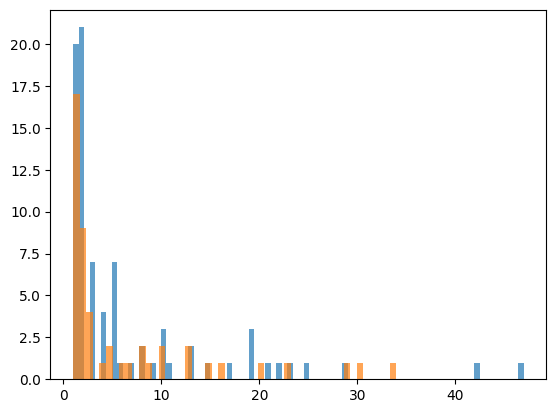

In [52]:
import matplotlib.pyplot as plt

join_sizes = [len(cluster['cluster']) for cluster in join_clusters['clusters']]
union_sizes = [len(cluster['cluster']) for cluster in union_clusters['clusters']]

plt.hist(union_sizes, alpha=0.7, bins=len(union_sizes))
plt.hist(join_sizes , alpha=0.7, bins=len(join_sizes))

plt.show()

### Comparison of JOIN and UNION schema

In [89]:
join_schemas = {cluster['key']: set(cluster['schema']) for cluster in join_clusters['clusters']}
union_schemas = {cluster['key']: set(cluster['schema']) for cluster in union_clusters['clusters']}

In [90]:
# Use Jaccard Similarity to compare the clusters
comparisons = {
    ckey_i: {
        ckey_j: len(attributes_i & attributes_j) / len(attributes_i | attributes_j)
        for ckey_j, attributes_j in join_schemas.items()
    }
    for ckey_i, attributes_i in union_schemas.items()
}

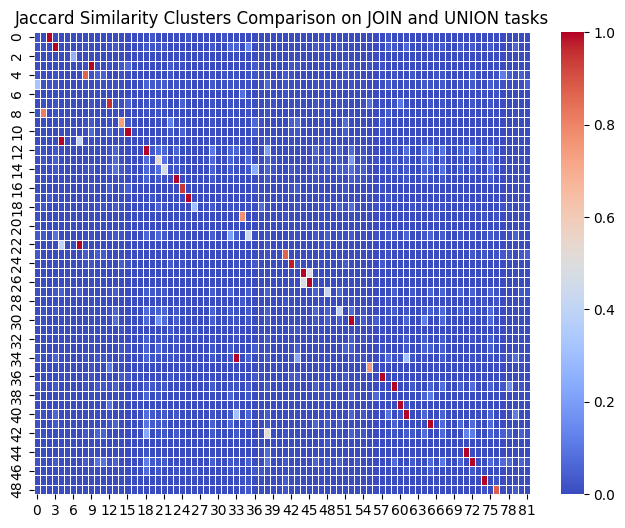

In [91]:
import seaborn as sns

df = pd.DataFrame(comparisons)

plt.figure(figsize=(8, 6))
plt.title('Jaccard Similarity Clusters Comparison on JOIN and UNION tasks')
sns.heatmap(df, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.show()

### Analyse Clusters from different Tasks that seems to have something in common

In [92]:
comparisons_list = list(filter(lambda x: 0.9 < x[2] <= 1, [[union_id, join_id, jac] for union_id, union_comp in comparisons.items() for join_id, jac in union_comp.items()]))
comparisons_list

[[2, 0, 1.0],
 [3, 1, 1.0],
 [4, 11, 1.0],
 [7, 22, 1.0],
 [9, 3, 1.0],
 [12, 7, 0.9540229885057471],
 [15, 10, 1.0],
 [18, 12, 1.0],
 [23, 15, 1.0],
 [24, 16, 0.9473684210526315],
 [25, 17, 1.0],
 [33, 34, 1.0],
 [42, 24, 0.9777777777777777],
 [44, 25, 1.0],
 [45, 26, 1.0],
 [52, 30, 1.0],
 [57, 36, 1.0],
 [59, 37, 1.0],
 [60, 39, 1.0],
 [61, 40, 1.0],
 [65, 41, 1.0],
 [71, 44, 1.0],
 [72, 45, 1.0],
 [74, 47, 1.0]]

In [93]:
n = 0
union_schemas[comparisons_list[n][0]] & join_schemas[comparisons_list[n][1]]

{'ADDRESS_LINE_1',
 'ADDRESS_LINE_2',
 'AFFILIATION_ENTITY_ID',
 'AFFILIATION_ENTITY_NAME',
 'ASSOCIATE_ID',
 'CCN',
 'CITY',
 'DOING_BUSINESS_AS_NAME',
 'ENROLLMENT_ID',
 'ENROLLMENT_STATE',
 'INCORPORATION_DATE',
 'INCORPORATION_STATE',
 'MULTIPLE_NPI_FLAG',
 'NPI',
 'NURSING_HOME_PROVIDER_NAME',
 'ORGANIZATION_NAME',
 'ORGANIZATION_TYPE_STRUCTURE',
 'PRACTICE_LOCATION_TYPE',
 'PROPRIETARY_NONPROFIT',
 'PROVIDER_TYPE_CODE',
 'PROVIDER_TYPE_TEXT',
 'STATE',
 'SUBGROUP_-_ACUTE_CARE',
 'SUBGROUP_-_ALCOHOL_DRUG',
 'SUBGROUP_-_CHILDRENS',
 'SUBGROUP_-_GENERAL',
 'SUBGROUP_-_LONG-TERM',
 'SUBGROUP_-_OTHER',
 'SUBGROUP_-_PSYCHIATRIC',
 'SUBGROUP_-_PSYCHIATRIC_UNIT',
 'SUBGROUP_-_REHABILITATION',
 'SUBGROUP_-_REHABILITATION_UNIT',
 'SUBGROUP_-_SHORT-TERM',
 'SUBGROUP_-_SPECIALTY_HOSPITAL',
 'SUBGROUP_-_SWING-BED_APPROVED',
 'ZIP_CODE'}